# PyNRPF v0.1.0 — Reproduce Key Numbers

This notebook:
1. reads config from `config/run.yaml`
2. loads `rpf_dataset.parquet` (downloads from Zenodo if missing and record_id is set)
3. runs validation checks via `src.validate`
4. applies time-based train/test split
5. builds day-level aggregation table
6. runs m7_threshold, m8_xgb, evaluation

In [1]:
# ── Environment + imports ─────────────────────────────────────────────────────
from pathlib import Path
import os, sys, random
from datetime import datetime

# Make src importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd

from src.io import (
    load_yaml, req, get, repo_root,
    verify_sha256_best_effort, load_parquet,
    write_json, ensure_dir,
)
from src.validate import basic_validate

print("Python:", sys.version)
print("CWD:   ", Path.cwd())
print("REPO:  ", REPO_ROOT)

Python: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
CWD:    C:\Users\z5404477\Documents\PyNRPF\notebooks
REPO:   C:\Users\z5404477\Documents\PyNRPF


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Single source of truth: config/run.yaml.  No hard-coded constants below.

CFG_PATH = REPO_ROOT / "config" / "run.yaml"
cfg = load_yaml(CFG_PATH)
print("Config loaded from:", CFG_PATH)

# -- Run settings
RUN_TAG = str(req(cfg, "run.run_tag"))
SEED    = int(req(cfg, "run.seed"))
random.seed(SEED)
np.random.seed(SEED)

# -- Paths
DATASET_PATH = (REPO_ROOT / str(req(cfg, "paths.dataset_parquet"))).resolve()
SHA_PATH     = (REPO_ROOT / str(req(cfg, "paths.sha256_file"))).resolve()
OUTPUT_DIR   = (REPO_ROOT / str(req(cfg, "paths.output_dir"))).resolve()
ensure_dir(OUTPUT_DIR)

# -- Column names
COL_SITE  = str(req(cfg, "data.columns.site"))
COL_TS    = str(req(cfg, "data.columns.ts"))
COL_NET   = str(req(cfg, "data.columns.net_load"))
COL_SOLAR = str(req(cfg, "data.columns.solar"))
COL_GT    = str(req(cfg, "data.columns.gt"))
ALL_COLS  = [COL_SITE, COL_TS, COL_NET, COL_SOLAR, COL_GT]

# -- Data settings
INTERVAL_MINUTES = int(req(cfg, "data.interval_minutes"))
MWH_FACTOR       = float(req(cfg, "data.mwh_factor"))

# -- Validation flags
VERIFY_SHA256           = bool(get(cfg, "validation.verify_sha256_best_effort", True))
STRIP_TIMEZONE          = bool(get(cfg, "validation.strip_timezone", True))
ENFORCE_INTERVAL_ALIGN  = bool(get(cfg, "validation.enforce_interval_alignment", True))
ENFORCE_UNIQUE_KEYS     = bool(get(cfg, "validation.enforce_unique_keys", True))

# -- Train / test split dates
TRAIN_START = str(req(cfg, "split.train_start"))
TRAIN_END   = str(req(cfg, "split.train_end"))
TEST_START  = str(req(cfg, "split.test_start"))
TEST_END    = str(req(cfg, "split.test_end"))

# -- Zenodo (for guarded download cell)
ZENODO_RECORD_ID = get(cfg, "zenodo.record_id")
ZENODO_FILENAME  = get(cfg, "zenodo.filename", "rpf_dataset.parquet")
ZENODO_TOKEN     = get(cfg, "zenodo.access_token")

print(f"RUN_TAG:  {RUN_TAG}")
print(f"SEED:     {SEED}")
print(f"DATASET:  {DATASET_PATH}")
print(f"COLUMNS:  {ALL_COLS}")
print(f"SPLIT:    train {TRAIN_START}..{TRAIN_END} | test {TEST_START}..{TEST_END}")

Config loaded from: C:\Users\z5404477\Documents\PyNRPF\config\run.yaml
RUN_TAG:  local_dev
SEED:     123
DATASET:  C:\Users\z5404477\Documents\PyNRPF\data\raw\rpf_dataset.parquet
COLUMNS:  ['substation_id', 'timestamp', 'net_load_MW', 'solar_MW', 'net_load_ground_truth']
SPLIT:    train 2021-11-01..2023-09-30 | test 2023-10-01..2024-09-30


In [3]:
# ── Download dataset from Zenodo (skipped if parquet exists locally) ───────────
import time, requests
from typing import Dict, Optional

def _http_get(url: str, headers: Dict[str, str], timeout: int = 60, retries: int = 4) -> requests.Response:
    last_err: Optional[Exception] = None
    for i in range(retries):
        try:
            r = requests.get(url, headers=headers, timeout=timeout)
            if r.status_code >= 500:
                raise RuntimeError(f"HTTP {r.status_code} from {url}")
            return r
        except Exception as e:
            last_err = e
            time.sleep(1.5 * (i + 1))
    raise RuntimeError(f"Failed GET after {retries} tries: {url} | last_err={last_err}")

def ensure_parquet_local() -> Optional[Path]:
    """Return path to local parquet if it exists or can be downloaded from Zenodo."""
    if DATASET_PATH.exists():
        print(f"Parquet found locally: {DATASET_PATH}")
        return DATASET_PATH

    if not ZENODO_RECORD_ID:
        print("Dataset not found locally, and zenodo.record_id is not set in config.")
        print("Either place the parquet at:", DATASET_PATH)
        print("Or set config/run.yaml -> zenodo.record_id to your Zenodo record number.")
        return None

    api_url = f"https://zenodo.org/api/records/{ZENODO_RECORD_ID}"
    headers = {"User-Agent": "PyNRPF/0.1.0 (reproducibility notebook)"}
    if ZENODO_TOKEN:
        headers["Authorization"] = f"Bearer {ZENODO_TOKEN}"

    print("Fetching Zenodo record:", api_url)
    r = _http_get(api_url, headers=headers)
    if r.status_code != 200:
        print(f"Failed to fetch Zenodo record (HTTP {r.status_code}).")
        return None

    meta = r.json()
    files = meta.get("files", []) or []
    target = None
    for f in files:
        key = f.get("key") or f.get("filename") or f.get("name")
        if key == ZENODO_FILENAME:
            target = f
            break

    if target is None:
        available = [x.get("key") or x.get("filename") or x.get("name") for x in files]
        print(f"Target file '{ZENODO_FILENAME}' not found. Available: {available}")
        return None

    dl_url = (target.get("links") or {}).get("self") or (target.get("links") or {}).get("download")
    if not dl_url:
        print("No usable download link in file metadata.")
        return None

    ensure_dir(DATASET_PATH.parent)
    tmp_path = DATASET_PATH.with_suffix(".parquet.part")
    print("Downloading:", dl_url)
    with requests.get(dl_url, headers=headers, stream=True, timeout=120) as resp:
        if resp.status_code != 200:
            print(f"Download failed (HTTP {resp.status_code}).")
            return None
        with open(tmp_path, "wb") as fp:
            for chunk in resp.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    fp.write(chunk)

    tmp_path.replace(DATASET_PATH)
    print("Saved:", DATASET_PATH)
    return DATASET_PATH

local_path = ensure_parquet_local()
if local_path is None:
    raise SystemExit("Stopping: no local dataset available.")

Parquet found locally: C:\Users\z5404477\Documents\PyNRPF\data\raw\rpf_dataset.parquet


In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
if VERIFY_SHA256:
    sha_result = verify_sha256_best_effort(local_path, SHA_PATH)
    print("SHA-256 check:", sha_result["status"],
          f"({sha_result.get('note', '')})" if sha_result.get("note") else "")

df = load_parquet(local_path)
print(df.dtypes)
df.head()

SHA-256 check: ok 
Loaded 1,011,264 rows x 5 cols from rpf_dataset.parquet
substation_id                         object
timestamp                datetime64[ns, UTC]
net_load_MW                          float64
solar_MW                             float64
net_load_ground_truth                float64
dtype: object


,substation_id,timestamp,net_load_MW,solar_MW,net_load_ground_truth
0,A,2021-11-01 00:15:00+00:00,NaN,0.0,NaN
1,A,2021-11-01 00:30:00+00:00,NaN,0.0,NaN
2,A,2021-11-01 00:45:00+00:00,NaN,0.0,NaN
3,A,2021-11-01 01:00:00+00:00,NaN,0.0,NaN
4,A,2021-11-01 01:15:00+00:00,12.515586,0.0,12.515586


In [5]:
# ── Validation ────────────────────────────────────────────────────────────────
result = basic_validate(
    df,
    cols_required=ALL_COLS,
    site_col=COL_SITE,
    ts_col=COL_TS,
    key_cols=[COL_SITE, COL_TS],
    interval_minutes=INTERVAL_MINUTES,
    strip_timezone=STRIP_TIMEZONE,
    enforce_interval_alignment=ENFORCE_INTERVAL_ALIGN,
    enforce_unique_keys=ENFORCE_UNIQUE_KEYS,
)

df = result["df"]
summary = result["summary"]

print("Validation passed.")
for k, v in summary.items():
    print(f"  {k}: {v}")

Validation passed.
  n_rows: 1011264
  n_sites: 10
  n_duplicate_keys: 0
  min_ts: 2021-11-01 00:15:00
  max_ts: 2024-09-30 00:00:00
  null_substation_id: 0
  null_timestamp: 0
  null_net_load_MW: 3000
  null_solar_MW: 1040
  null_net_load_ground_truth: 3000


In [6]:
# ── Train / test split ────────────────────────────────────────────────────────
df["date"] = df[COL_TS].dt.date

train_mask = (df["date"] >= pd.Timestamp(TRAIN_START).date()) & (df["date"] <= pd.Timestamp(TRAIN_END).date())
test_mask  = (df["date"] >= pd.Timestamp(TEST_START).date())  & (df["date"] <= pd.Timestamp(TEST_END).date())

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

print(f"Train: {len(df_train):,} rows  ({TRAIN_START} to {TRAIN_END})")
print(f"Test:  {len(df_test):,} rows  ({TEST_START} to {TEST_END})")
print(f"Other: {(~train_mask & ~test_mask).sum():,} rows outside split range")

Train: 666,432 rows  (2021-11-01 to 2023-09-30)
Test:  344,832 rows  (2023-10-01 to 2024-09-30)
Other: 0 rows outside split range


In [7]:
# ── Day-level aggregation ─────────────────────────────────────────────────────
day_df = (
    df.groupby([COL_SITE, "date"])
    .agg(
        n_intervals=(COL_TS, "count"),
        any_gt_neg=(COL_GT, lambda s: int((s < 0).any())),
    )
    .reset_index()
)

print(f"Day-level rows: {len(day_df):,}")
print(f"  Sites: {day_df[COL_SITE].nunique()}")
print(f"  Days with RPF (ground truth): {day_df['any_gt_neg'].sum():,} / {len(day_df):,}")
day_df.head()

Day-level rows: 10,643
  Sites: 10
  Days with RPF (ground truth): 3,423 / 10,643


,substation_id,date,n_intervals,any_gt_neg
0,A,2021-11-01,95,0
1,A,2021-11-02,96,0
2,A,2021-11-03,96,0
3,A,2021-11-04,96,0
4,A,2021-11-05,96,0


In [8]:
# ── m7_threshold ──────────────────────────────────────────────────────────────
# Deterministic detection + correction method (DTR).
# Config: cfg["m7_threshold"]

from src.m7_threshold import run_m7

df = run_m7(df, cfg, COL_SITE, COL_TS, COL_NET, COL_SOLAR)

# Per-site summary
m7_site = (
    df.groupby(COL_SITE)
    .agg(
        intervals_flagged=("m7_rpf_flag", "sum"),
        days_flagged=("m7_rpf_day", lambda s: s.any()),  # just a check
    )
)
print("\nPer-site m7 flagged intervals:")
print(m7_site.to_string())

# Update day_df with m7 day-level predictions
day_m7 = df.groupby([COL_SITE, "date"])["m7_rpf_flag"].any().reset_index(name="m7_rpf_day")
day_df = day_df.merge(day_m7, on=[COL_SITE, "date"], how="left")
day_df["m7_rpf_day"] = day_df["m7_rpf_day"].fillna(False)

print(f"\nDay-level: {int(day_df['m7_rpf_day'].sum()):,} days flagged by m7 "
      f"(ground truth: {int(day_df['any_gt_neg'].sum()):,})")


m7_threshold complete (1.6s):
  Site-days total:           10,643
  Skipped (missing data):    90
  Skipped (negative MW):     0
  Skipped (midday < 3 pts):  109
  Skipped (no candidates):   191
  Skipped (no valid pair):   5,514
  Skipped (threshold gate):  1,022
  Skipped (daytime gate):    3
  RPF days flagged:          3,714
  Intervals flagged:         44,769
  Thresholds: min=5.00%, both=25.00%

Per-site m7 flagged intervals:
               intervals_flagged  days_flagged
substation_id                                 
A                              0         False
B                            234          True
C                           7732          True
D                              0         False
E                           9307          True
F                          12475          True
G                           8819          True
H                              0         False
I                           1843          True
J                           4359          True

In [9]:
# ── m8_xgb ────────────────────────────────────────────────────────────────────
# XGBoost day + timestamp classification.
# Config: cfg["m8_xgb"]["xgb1_day"], cfg["m8_xgb"]["xgb2_timestamp"]
from src.m8_xgb import run_m8

df = run_m8(df, cfg, COL_SITE, COL_TS, COL_NET, COL_SOLAR, COL_GT)

# Day-level confusion on test set
day_m8 = df.loc[test_mask].groupby([COL_SITE, "date"]).agg(
    m8_pred=("m8_rpf_day", "first"),
    min_gt=(COL_GT, "min"),
).reset_index()
day_m8["y_true"] = day_m8["min_gt"] < 0
tp = ((day_m8.m8_pred) & (day_m8.y_true)).sum()
fp = ((day_m8.m8_pred) & (~day_m8.y_true)).sum()
fn = ((~day_m8.m8_pred) & (day_m8.y_true)).sum()
tn = ((~day_m8.m8_pred) & (~day_m8.y_true)).sum()
P = tp/(tp+fp) if (tp+fp) else 0
R = tp/(tp+fn) if (tp+fn) else 0
F1 = 2*P*R/(P+R) if (P+R) else 0
print(f"\n=== m8_xgb Day-Level TEST SET ===")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  P={P:.3f}  R={R:.3f}  F1={F1:.3f}")
print(f"  Target: F1 > 0.95")

STAGE 1: XGB1 day-level classification


XGB1 features: 221 columns, 10,643 rows (3,423 positive)
  Train: 6,986 rows (2,095 positive)
  Test:  3,657 rows (1,328 positive)


  [XGB1 TEST] TP=1272  FP=62  FN=56  TN=2267  P=0.954  R=0.958  F1=0.956
  Model saved: C:\Users\z5404477\Documents\PyNRPF\outputs\xgb1_day.pkl

STAGE 2: XGB2 interval-level classification
  XGB1-positive site-days: 3,429


XGB2 features: 665 columns, 178,308 rows (47,753 positive)


  Train: 108,940 rows (27,678 positive)
  Test:  69,368 rows (20,075 positive)


  [XGB2 TEST] TP=15980  FP=1348  FN=4095  TN=47945  P=0.922  R=0.796  F1=0.854
  Model saved: C:\Users\z5404477\Documents\PyNRPF\outputs\xgb2_timestamp.pkl

Mapping results to original DataFrame


C:\Users\z5404477\Documents\PyNRPF\src\m8_xgb.py:227: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result["m8_rpf_flag"] = result["m8_rpf_flag"].fillna(False).infer_objects(copy=False).astype(bool)



m8_xgb complete (72.8s):
  Days flagged (XGB1):       3,429
  Intervals flagged (XGB2):  41,312
  Thresholds: xgb1=0.585985, xgb2=0.892234



=== m8_xgb Day-Level TEST SET ===
  TP=1272  FP=62  FN=56  TN=2267
  P=0.954  R=0.958  F1=0.956
  Target: F1 > 0.95


In [10]:
# ── Evaluation ─────────────────────────────────────────────────────────────────
# Ground truth (COL_GT) is used ONLY here for scoring — never in m7/m8 logic.

from src.evaluate import evaluate_method

eval_rounding = int(cfg.get("evaluation", {}).get("rounding", 3))
split_cfg = {"train_end": TRAIN_END, "test_start": TEST_START}

# m7_threshold evaluation
m7_results = evaluate_method(
    df, COL_SITE, COL_TS, COL_NET, COL_GT,
    pred_day_col="m7_rpf_day",
    pred_flag_col="m7_rpf_flag",
    split_cfg=split_cfg,
    method_name="m7_threshold (DTR)",
    rounding=eval_rounding,
)

# m8_xgb evaluation
m8_results = evaluate_method(
    df, COL_SITE, COL_TS, COL_NET, COL_GT,
    pred_day_col="m8_rpf_day",
    pred_flag_col="m8_rpf_flag",
    split_cfg=split_cfg,
    method_name="m8_xgb (XGBoost)",
    rounding=eval_rounding,
)


  Evaluation: m7_threshold (DTR)

  Day-level (m7_rpf_day)  [excluded 0 days with negative MW]
  [TRAIN]  TP=2054  FP=257  FN=41  TN=4634  P=0.889  R=0.980  F1=0.932
  [TEST ]  TP=1279  FP=124  FN=49  TN=2205  P=0.912  R=0.963  F1=0.937



  Interval-level (m7_rpf_flag) (all predicted-positive days)
  [TRAIN]  TP=21076  FP=5056  FN=6282  TN=78514  P=0.807  R=0.770  F1=0.788
  [TEST ]  TP=15723  FP=2914  FN=4037  TN=44670  P=0.844  R=0.796  F1=0.819



  Interval-level (m7_rpf_flag) (TP days only)
  [TRAIN]  TP=21076  FP=4005  FN=6282  TN=67229  P=0.840  R=0.770  F1=0.804
  [TEST ]  TP=15723  FP=2367  FN=4037  TN=39265  P=0.869  R=0.796  F1=0.831

  Evaluation: m8_xgb (XGBoost)

  Day-level (m8_rpf_day)  [excluded 0 days with negative MW]
  [TRAIN]  TP=2095  FP=0  FN=0  TN=4891  P=1.000  R=1.000  F1=1.000
  [TEST ]  TP=1272  FP=62  FN=56  TN=2267  P=0.954  R=0.958  F1=0.956



  Interval-level (m8_rpf_flag) (all predicted-positive days)
  [TRAIN]  TP=23203  FP=781  FN=4470  TN=72106  P=0.967  R=0.838  F1=0.898
  [TEST ]  TP=15980  FP=1348  FN=4095  TN=42609  P=0.922  R=0.796  F1=0.854



  Interval-level (m8_rpf_flag) (TP days only)
  [TRAIN]  TP=23203  FP=781  FN=4470  TN=72106  P=0.967  R=0.838  F1=0.898
  [TEST ]  TP=15980  FP=1235  FN=4095  TN=39746  P=0.928  R=0.796  F1=0.857



Confusion matrix plot saved: C:\Users\z5404477\Documents\PyNRPF\outputs\confusion_matrices.png


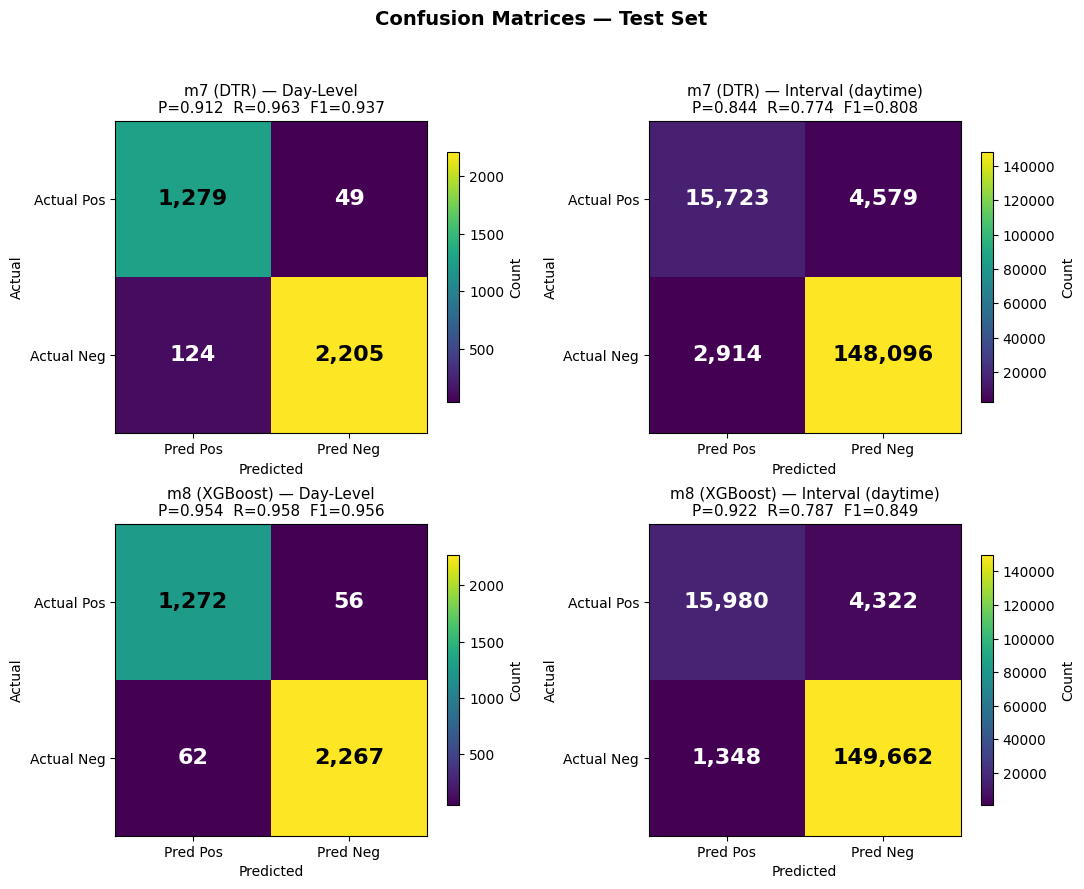

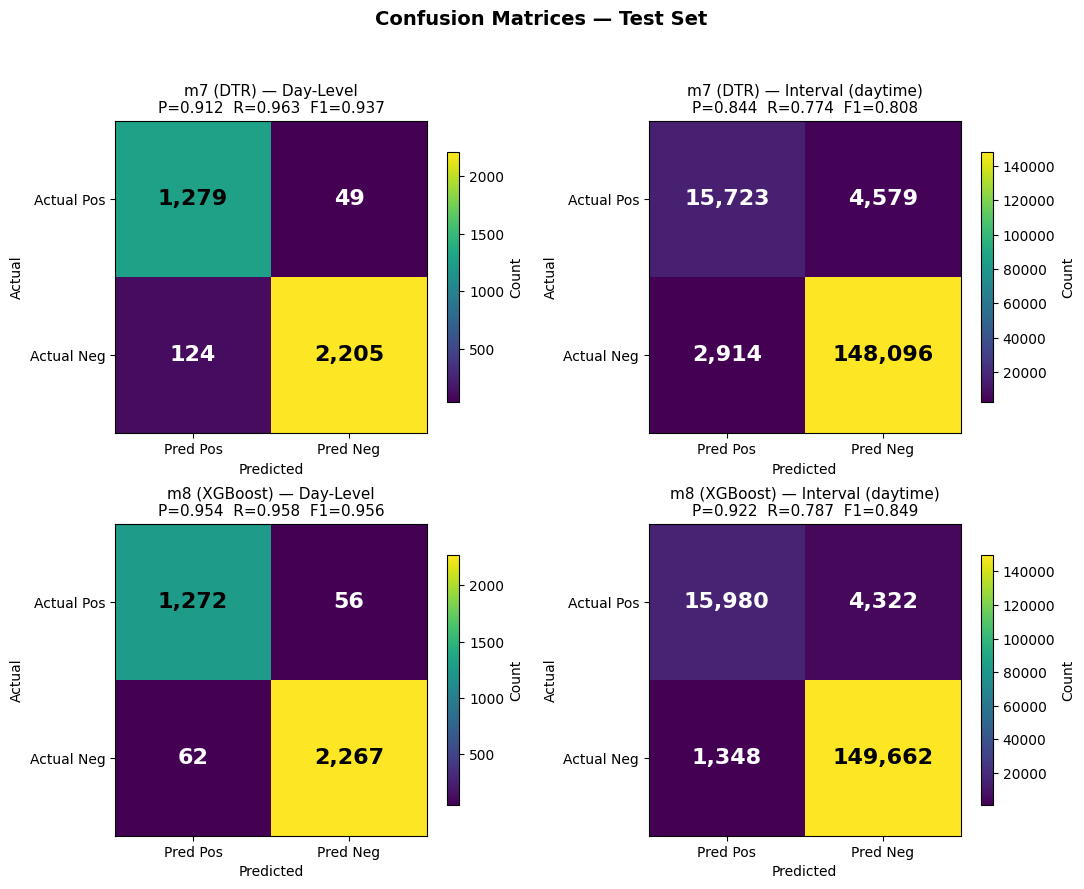

In [11]:
# ── Confusion matrix plots (test set) ──────────────────────────────────────────
from src.evaluate import plot_all_confusion_matrices

fig = plot_all_confusion_matrices(
    df, COL_SITE, COL_TS, COL_NET, COL_GT,
    split_cfg=split_cfg,
    output_path=OUTPUT_DIR / "confusion_matrices.png",
)
fig  # display inline

In [12]:
# ── Export metrics JSON + YAML ─────────────────────────────────────────────────
from datetime import timezone
from src.io import write_yaml

METRICS_JSON = OUTPUT_DIR / f"metrics__{RUN_TAG}.json"
METRICS_YAML = OUTPUT_DIR / f"metrics__{RUN_TAG}.yaml"

metrics = {
    "run_tag": RUN_TAG,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": str(local_path),
    "split": {
        "train_start": TRAIN_START,
        "train_end": TRAIN_END,
        "test_start": TEST_START,
        "test_end": TEST_END,
    },
    "data_summary": {
        "n_rows": summary["n_rows"],
        "n_sites": summary["n_sites"],
        "n_train_rows": len(df_train),
        "n_test_rows": len(df_test),
        "n_day_rows": len(day_df),
        **{k: v for k, v in summary.items() if k.startswith("null_")},
    },
    "m7_threshold": m7_results,
    "m8_xgb": m8_results,
}

write_json(METRICS_JSON, metrics)
write_yaml(METRICS_YAML, metrics)

print(f"Wrote: {METRICS_JSON}")
print(f"Wrote: {METRICS_YAML}")
print(f"\n=== Done ===")

Wrote: C:\Users\z5404477\Documents\PyNRPF\outputs\metrics__local_dev.json
Wrote: C:\Users\z5404477\Documents\PyNRPF\outputs\metrics__local_dev.yaml

=== Done ===
